# Super Guassian Plotting
Notebook for plotting and manipulating super giuassian profiles

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Super guassian equation according to [Wikipedia](https://en.wikipedia.org/wiki/Gaussian_function#Higher-order_Gaussian_or_super-Gaussian_function_or_generalized_Gaussian_function):

$f(x) = A exp (-(\frac{(x - x_0)^2}{2\sigma^2_X})^P)$

Simplified down:
    
$f(x) = exp(-(ax)^P)$

In [67]:
def simpleSuperGuassian(a, x, P):
    return np.exp( -(a*np.abs(x))**P )
    

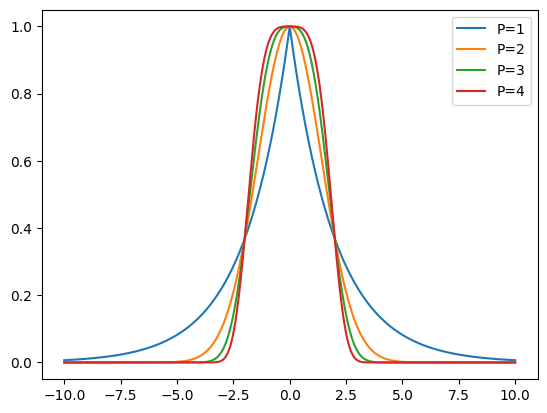

In [96]:
# Source - https://stackoverflow.com/q/60771917
# Posted by Ida, modified by community. See post 'Timeline' for change history
# Retrieved 2026-06-04, License - CC BY-SA 4.0

# Dummy x data
x = np.linspace(-10,10,1000)

a=0.5

for P in [1, 2, 3, 4]:
    plt.plot(x, simpleSuperGuassian(a,x,P), label=f"P={P}");
plt.legend();


## Application to LaserbeamFoam

From [LaserbeamFoam paper](https://www.sciencedirect.com/science/article/pii/S2352711022002175):

$q = exp( -((\frac{x-b_g}{r})^2 + (\frac{z-vt-l_g}{r}) )^P)$

Where:
$q$ is energy
$x$ is x values
$b_g$ is offset to x position
$r$ is beam radius in $1/e^2$ basis
$z$ is z position (beam travel direction)
$v$ is velocity (how does this affect beam profile?)
$l_g$ offset in beam travel direction
$P$ is power of superguassian (how flat peak is)

Simplifying:
$q = exp( -((\frac{x}{r})^2)^P )$

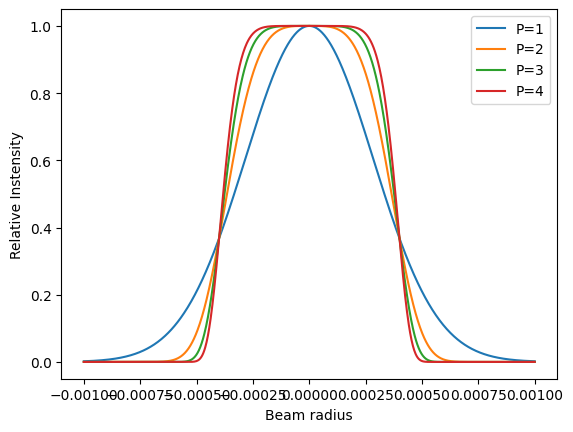

In [87]:
def LaserbeamSuperGuassian(x, r, P):
    return np.exp( -((x/r)**2)**P )

# Dummy x data
x = np.linspace(-0.001,0.001,1000)
r = 0.0004

for P in [1, 2, 3, 4]:
    plt.plot(x, LaserbeamSuperGuassian(x, r, P), label=f"P={P}")
    
plt.xlabel("Beam radius")
plt.ylabel("Relative Instensity")
plt.legend();